# PCA, t-SNE, and UMAP: TB at diagnosis vs healthy controls

Compares blood gene expression of **TB patients at diagnosis** (before treatment) with **healthy controls** from SRP092402, using three dimension-reduction methods.

Requires `data/SRP092402/SRP092402_Symbols.tsv` from `gene_id_annotation.R`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

data_dir = Path("../data/SRP092402")
results_dir = Path(".")  # notebooks live in results/, next to their outputs

SEED = 42
group_colors = {"TB (diagnosis)": "#d95f02", "Healthy control": "#1b9e77"}

## Load expression data and metadata

In [2]:
expression_df = pd.read_csv(data_dir / "SRP092402_Symbols.tsv", sep="\t", index_col="Ensembl")
expression_mat = expression_df.drop(columns=["first_mapped_symbol", "all_symbols"])

metadata = pd.read_csv(data_dir / "metadata_SRP092402.tsv", sep="\t")
print(expression_mat.shape, metadata.shape)

(43363, 909) (909, 24)


## Pick the two groups

Keep diagnosis (`dx`) samples from TB subjects and healthy controls.

In [3]:
group_labels = {"tb subjects": "TB (diagnosis)", "healthy controls": "Healthy control"}

selected = metadata[
    metadata["refinebio_disease"].isin(group_labels)
    & (metadata["refinebio_time"] == "dx")
].copy()
selected["group"] = selected["refinebio_disease"].map(group_labels)

selected["group"].value_counts()

group
TB (diagnosis)     181
Healthy control     50
Name: count, dtype: int64

## Merge technical replicates

Most blood samples were sequenced on two lanes, giving two runs (SRR IDs) with nearly identical values. Left in, each pair would sit on top of itself in the plots and count twice. Average the runs from the same subject and timepoint so each point is one biological sample.

In [4]:
log_mat = np.log2(expression_mat[selected["refinebio_accession_code"]] + 1)

selected["sample_id"] = "S" + selected["refinebio_subject"].astype(str) + "_" + selected["refinebio_time"]
run_to_sample = selected.set_index("refinebio_accession_code")["sample_id"]

sample_mat = log_mat.T.groupby(run_to_sample).mean().T
sample_info = selected.drop_duplicates("sample_id").set_index("sample_id").loc[sample_mat.columns]

print(f"{log_mat.shape[1]} runs -> {sample_mat.shape[1]} biological samples")
sample_info["group"].value_counts()

231 runs -> 112 biological samples


group
TB (diagnosis)     91
Healthy control    21
Name: count, dtype: int64

## Filter and select genes

1. Drop genes with median log2 expression below 1 (mostly unexpressed; see `explore_expression.ipynb`).
2. Keep the 500 most variable remaining genes, the same default DESeq2's `plotPCA()` uses.

In [5]:
expressed = sample_mat[sample_mat.median(axis=1) >= 1]
top_genes = expressed.var(axis=1).nlargest(500).index
top_mat = expressed.loc[top_genes]

print(f"Expressed genes: {len(expressed):,}; using the top {len(top_genes)} most variable")

# Samples as rows, genes as columns
X = top_mat.T.values
groups = sample_info["group"].values

Expressed genes: 18,293; using the top 500 most variable


In [6]:
def plot_embedding(coords, title, xlabel, ylabel, filename):
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.scatterplot(
        x=coords[:, 0], y=coords[:, 1], hue=groups, palette=group_colors,
        s=60, alpha=0.85, edgecolor="white", ax=ax,
    )
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.legend(title="Group")
    fig.savefig(results_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()

## PCA

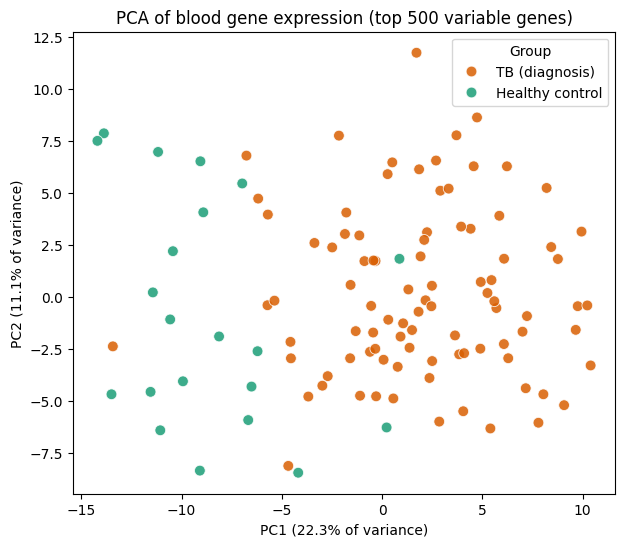

Variance explained by PC1-5 (%): [22.3 11.1  7.8  6.7  6.6]


In [7]:
pca = PCA(n_components=10, random_state=SEED)
pca_coords = pca.fit_transform(X - X.mean(axis=0))
var_pct = pca.explained_variance_ratio_ * 100

plot_embedding(
    pca_coords,
    "PCA of blood gene expression (top 500 variable genes)",
    f"PC1 ({var_pct[0]:.1f}% of variance)",
    f"PC2 ({var_pct[1]:.1f}% of variance)",
    "pca_tb_vs_healthy.png",
)
print("Variance explained by PC1-5 (%):", var_pct[:5].round(1))

## t-SNE

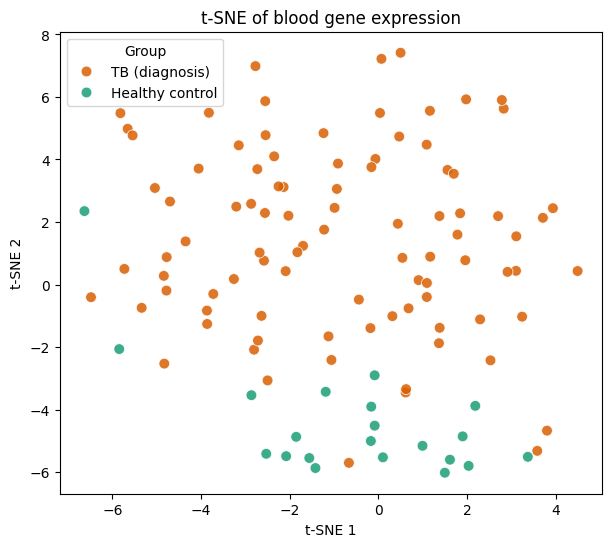

In [8]:
tsne = TSNE(n_components=2, perplexity=30, init="pca", random_state=SEED)
tsne_coords = tsne.fit_transform(X)

plot_embedding(tsne_coords, "t-SNE of blood gene expression", "t-SNE 1", "t-SNE 2", "tsne_tb_vs_healthy.png")

## UMAP

C:\Users\richa\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


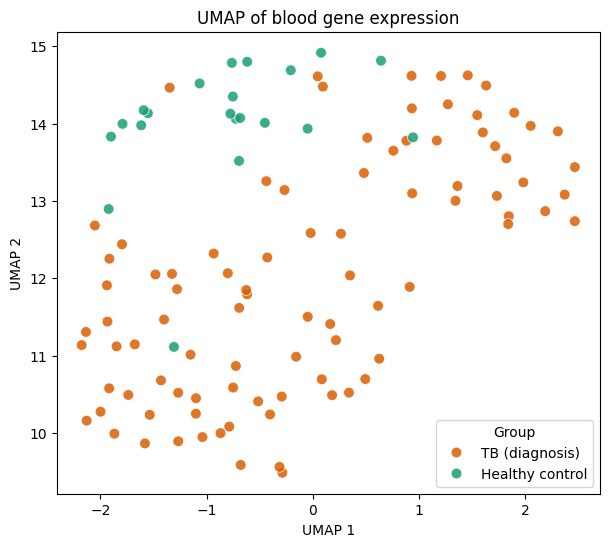

In [9]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=SEED)
umap_coords = reducer.fit_transform(X)

plot_embedding(umap_coords, "UMAP of blood gene expression", "UMAP 1", "UMAP 2", "umap_tb_vs_healthy.png")

## Which genes drive the separation?

Genes with the largest weights on PC1, and a simple check of how well PC1 alone separates the groups.

In [10]:
symbols = expression_df.loc[top_genes, "first_mapped_symbol"]
loadings = pd.Series(pca.components_[0], index=top_genes)
top_loadings = loadings.abs().nlargest(15).index
print(pd.DataFrame({"symbol": symbols[top_loadings], "PC1 loading": loadings[top_loadings].round(3)}).to_string())

pc_df = pd.DataFrame({"PC1": pca_coords[:, 0], "PC2": pca_coords[:, 1], "group": groups})
print("\nMean PC1 / PC2 by group:")
print(pc_df.groupby("group")[["PC1", "PC2"]].mean().round(2))

                   symbol  PC1 loading
Ensembl                               
ENSG00000149131  SERPING1        0.157
ENSG00000150337    FCGR1A        0.127
ENSG00000168062     BATF2        0.122
ENSG00000154451      GBP5        0.118
ENSG00000117228      GBP1        0.113
ENSG00000142089    IFITM3        0.113
ENSG00000198019       NaN        0.107
ENSG00000133106    EPSTI1        0.107
ENSG00000204936     CD177        0.105
ENSG00000203812       NaN        0.104
ENSG00000206047     DEFA1        0.101
ENSG00000152766   ANKRD22        0.099
ENSG00000119917     IFIT3        0.096
ENSG00000120217     CD274        0.096
ENSG00000134321     RSAD2        0.092

Mean PC1 / PC2 by group:
                  PC1   PC2
group                      
Healthy control -8.68 -0.75
TB (diagnosis)   2.00  0.17


## Summary

**Data:** 112 biological samples (91 TB at diagnosis, 21 healthy controls) after averaging technical replicates, using the 500 most variable of the 18,293 expressed genes.

**PCA**
- PC1 explains 22.3% of the variance and PC2 11.1%.
- The groups separate mostly along PC1: healthy controls sit on the left (mean PC1 about -8.7) and TB patients on the right (mean about +2.0). There is overlap in the middle, where some TB patients look like healthy controls.
- PC2 doesn't separate the groups; it captures other variation between people.
- The genes driving PC1 are classic TB blood-signature genes: interferon-response genes (GBP1, GBP5, BATF2, SERPING1, IFITM3, EPSTI1, IFIT3, RSAD2, ANKRD22), the immune receptor FCGR1A, the immune checkpoint CD274 (PD-L1), and neutrophil genes (CD177, DEFA1). So the main source of variation in this data is the immune response to TB.

**t-SNE**
- Healthy controls form a fairly tight group at the bottom of the plot, and TB patients fill the rest. The separation looks sharper than in PCA, but a handful of TB patients still sit among the controls.

**UMAP**
- Healthy controls again cluster together (top left), with TB patients spread over a larger region. UMAP also splits the TB patients into two loose subgroups (upper right and lower left), which PCA shows only as a spread along PC1. These could reflect differences in disease severity, but would need checking.

**Similarities**
- All three methods show the same main result: healthy controls are more alike than TB patients are, and TB patients are shifted away from them, with partial overlap.
- The same few TB samples land near the controls in every plot. These may be patients with milder disease.

**Differences**
- **PCA** is linear and keeps global distances, so axis values mean something (percent of variance, gene loadings), but the groups overlap more visually.
- **t-SNE and UMAP** are non-linear and focus on local neighborhoods, so they pull similar samples into tighter clusters and make the groups look more separated. Their axes have no units, distances between clusters are not directly meaningful, and the layout changes with the random seed and settings (perplexity, n_neighbors).
- **UMAP** kept more of the larger-scale structure than t-SNE, such as the possible two TB subgroups.